<div style="text-align: right;">
Regina Tamayo León<br>
Elisa Aguirre Arias<br>
Alan Yael Almaraz</div>

# **P02: PROYECTO 03 CREDIT CARD CLIENT**

**Análisis Predictivo de Incumplimiento de Pago en Clientes de Tarjetas de Crédito mediante Técnicas de Aprendizaje Automático**

### 1. Objetivos

**1.1 Objetivo General**: Desarrollar un estudio comparativo utilizando modelos de aprendizaje supervisado para predecir la probabilidad de incumplimiento de pago de clientes de tarjetas de crédito en Taiwán, optimizando su rendimiento mediante procesos gaussianos.

**1.2 Objetivos específicos**: 

- Realizar un análisis exploratorio de datos (EDA) para identificar patrones de riesgo.
- Preprocesar y transformar las variables del dataset para su correcta implementación en modelos de clasificación.
- Implementar y ajustar modelos de Regresión Logística, SVM y Redes Neuronales (MLP).
- Optimizar los hiperparámetros de cada modelo mediante Optimización Bayesiana.
- Comparar el desempeño de los modelos utilizando métricas de exactitud, sensibilidad y F1-Score.
__________________

### 2. Marco Teórico
**2.1 Regresión logística:** 
Modelo estadístico utilizado para predecir la probabilidad de una variable dependiente binaria (default o no default) basándose en variables independientes.

**2.2 Máquinas de vectores de soporte (SVM):** 
Algoritmo que busca el hiperplano óptimo que maximiza el margen de separación entre clases en un espacio de alta dimensión.

**2.3 Redes neuronales (MLP):** 
Modelo inspirado en la estructura biológica del cerebro, compuesto por capas de neuronas (entrada, ocultas y salida) capaces de aprender relaciones no lineales complejas.

**2.4 Kernels:** 
Funciones que permiten a algoritmos como SVM operar en espacios de características transformados sin necesidad de calcular coordenadas en ese espacio, como el kernel RBF (Radial Basis Function).

**2.5 Métricas para clasificación:** 
Herramientas de evaluación como la Exactitud (proporción de predicciones correctas), Sensibilidad (capacidad de detectar positivos reales) y F1-Score (balance entre precisión y sensibilidad).

**2.6 Hiperparámetros:** 
Parámetros configurables del modelo que no se aprenden durante el entrenamiento y que controlan el proceso de aprendizaje.

**2.7 Optimización Bayesiana:** 
Estrategia para la búsqueda de hiperparámetros óptimos que utiliza modelos probabilísticos (procesos gaussianos) para minimizar una función objetivo de forma eficiente.

**2.8 Evaluación del Riesgo de Impago (Default):**
El riesgo crediticio es la probabilidad de pérdida por el incumplimiento de un cliente. El "default" se define como la incapacidad de realizar el pago mínimo mensual de la tarjeta de crédito. La detección temprana mediante datos históricos permite a las instituciones financieras mitigar pérdidas y optimizar la asignación de líneas de crédito.

**2.9 Comportamiento vs. Demografía**
El análisis moderno de riesgo divide los datos en dos tipos:

- Variables Estáticas (Demográficas): Edad, educación y estado civil. Ayudan a crear un perfil inicial, pero son menos predictivas a corto plazo.

- Variables Dinámicas (Comportamiento): Historial de pagos y saldos mensuales. En el análisis de riesgo, estas variables son críticas porque reflejan la liquidez y la voluntad de pago inmediata del usuario.

__________________

### 3. Análisis de Dataset

**3.1 ¿De dónde viene?**
El conjunto de datos proviene del UCI Machine Learning Repository, titulado "Default of Credit Card Clients". Fue recolectado originalmente en Taiwán por investigadores de la Universidad de Chung Hua y la Universidad de Union. Representa un esfuerzo por mejorar la precisión de las predicciones de solvencia en el sector bancario asiático durante el año 2005.

**3.2 ¿Qué contiene?**
Contiene un total de 30,000 registros (muestras) y 25 columnas (variables). Las variables se dividen en cuatro categorías principales:

- Demográficas: Género, educación, estado civil y edad.

- Historial de crédito: El monto del crédito otorgado (LIMIT_BAL).

- Historial de pagos: Registros de puntualidad o retraso en los pagos de los últimos 6 meses (PAY_0 a PAY_6).

- Estado de cuenta y pagos realizados: Montos facturados mensualmente y cuánto pagó efectivamente el cliente.

**3.3 ¿Qué información dan las muestras?**
Cada muestra representa el perfil financiero de un cliente individual. Proporciona una "fotografía" de su comportamiento: nos dice qué tan educado es el cliente, cuánto crédito tiene permitido gastar, si tiene el hábito de pagar a tiempo o si ha arrastrado deudas durante meses, y finalmente, si incumplió su pago el mes siguiente.

**3.4 ¿Qué se quiere analizar?**
El objetivo central es identificar el perfil de riesgo. Se busca determinar qué factores (como el nivel educativo o un retraso de dos meses en el pago de abril) aumentan significativamente la probabilidad de que un cliente caiga en mora (default). Básicamente, se quiere transformar datos históricos en una herramienta de prevención de pérdidas.

**3.5 ¿Qué variables se tienen que transformar y qué transformaciones se usarán?**
Para que los modelos de regresión y clasificación funcionen correctamente, los datos crudos no pueden entrar directamente:

1. Variables Categóricas (SEX, EDUCATION, MARRIAGE): Se deben transformar mediante One-Hot Encoding. Esto crea columnas binarias (0 y 1) para que el modelo no asuma que el estado civil "2" es el doble que el "1".

2. Variables Numéricas (LIMIT_BAL, AGE, montos de facturación): Requieren Escalamiento Estándar (StandardScaler). Esto ajusta los datos para que tengan media 0 y desviación estándar 1, evitando que las variables con números muy grandes (como un crédito de 500,000) dominen injustamente sobre variables pequeñas (como la edad).

**3.6 ¿Qué resultado se podría encontrar al realizar una regresión?**
Al realizar la regresión logística, el resultado principal es un coeficiente para cada variable. Estos coeficientes nos permiten concluir cosas como:

"Por cada mes de retraso en el último pago, la probabilidad de default aumenta un X%."

"Los clientes con mayor límite de crédito tienden a tener una menor probabilidad de incumplimiento."
Además, la regresión nos da un score de probabilidad del 0 al 1 para cada cliente, permitiendo al banco decidir a quién otorgar o cancelar tarjetas.
__________________

**Carga y limpieza de datos**

In [3]:
import pandas as pd

In [5]:
df = pd.read_csv('UCI_Credit_Card.csv')
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [5]:
# Vemos los valores únicos
for column in df.columns:
    print(f'{column}: {df[column].unique()}unique values')

ID: [    1     2     3 ... 29998 29999 30000]unique values
LIMIT_BAL: [  20000.  120000.   90000.   50000.  500000.  100000.  140000.  200000.
  260000.  630000.   70000.  250000.  320000.  360000.  180000.  130000.
  450000.   60000.  230000.  160000.  280000.   10000.   40000.  210000.
  150000.  380000.  310000.  400000.   80000.  290000.  340000.  300000.
   30000.  240000.  470000.  480000.  350000.  330000.  110000.  420000.
  170000.  370000.  270000.  220000.  190000.  510000.  460000.  440000.
  410000.  490000.  390000.  580000.  600000.  620000.  610000.  700000.
  670000.  680000.  430000.  550000.  540000. 1000000.  530000.  710000.
  560000.  520000.  750000.  640000.   16000.  570000.  590000.  660000.
  720000.  327680.  740000.  800000.  760000.  690000.  650000.  780000.
  730000.]unique values
SEX: [2 1]unique values
EDUCATION: [2 1 3 5 4 6 0]unique values
MARRIAGE: [1 2 3 0]unique values
AGE: [24 26 34 37 57 29 23 28 35 51 41 30 49 39 40 27 47 33 32 54 58 22 25 31
 

In [6]:
num_vars = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 
            'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 
            'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

cat_vars = ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_2', 
            'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

print(f"Numéricas: {len(num_vars)} | Categóricas: {len(cat_vars)}")

Numéricas: 14 | Categóricas: 9


**Histogramas**

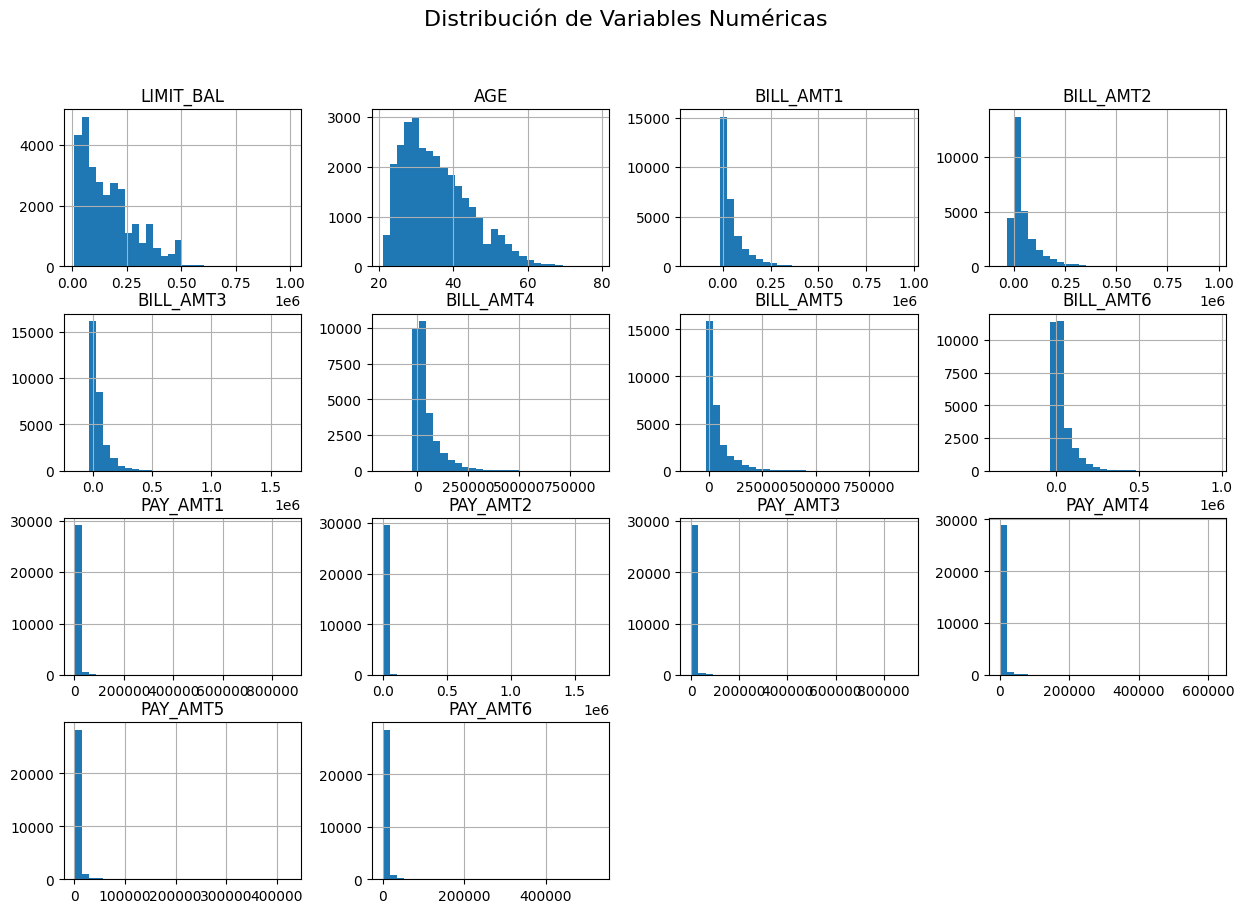

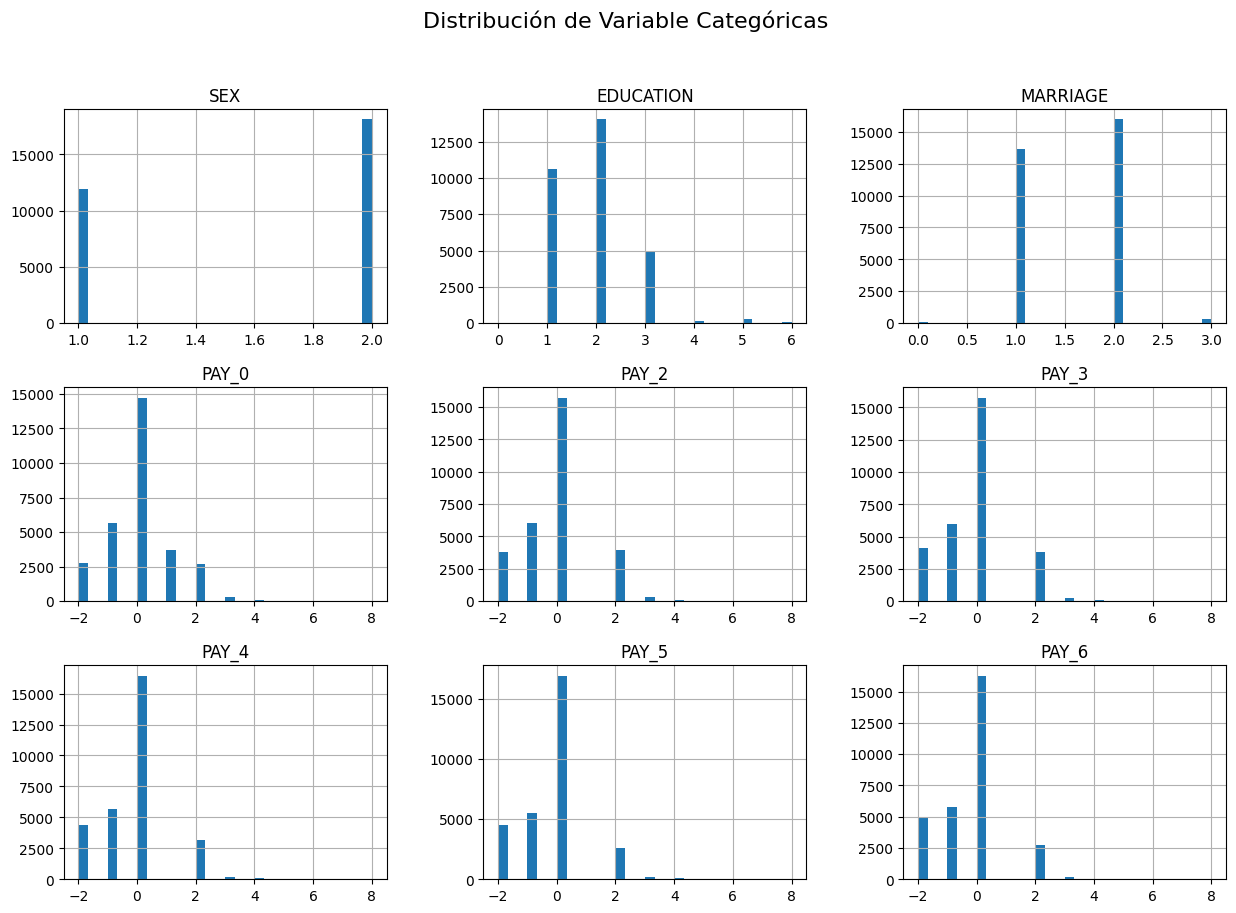

In [7]:
import matplotlib.pyplot as plt

# para variables numéricas
df[num_vars].hist(bins=30, figsize=(15, 10))
plt.suptitle("Distribución de Variables Numéricas", fontsize=16)
plt.show()
# para variables categoricas
df[cat_vars].hist(bins=30, figsize=(15, 10))
plt.suptitle("Distribución de Variable Categóricas", fontsize=16)
plt.show()

### **Procedimiento**

#### **Multi-layer perceptron**

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from skopt import BayesSearchCV

X = df.drop('default.payment.next.month', axis=1)
y = df['default.payment.next.month']


col_categoricas = ['SEX', 'EDUCATION', 'MARRIAGE'] 
col_numericas = [col for col in X.columns if col not in col_categoricas]

# Escalamiento para numéricas y One-Hot para categóricas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), col_numericas),
        ('cat', OneHotEncoder(), col_categoricas),
    ]
)

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


pipe_mlp = Pipeline([
    ('prepro', preprocessor),
    ('clf', MLPClassifier(max_iter=1000, early_stopping=True, random_state=42))
])


search_space_mlp = {
    'clf__hidden_layer_sizes': [(50,), (100,), (50, 25), (100, 50)], # tuplas fijas
    'clf__activation': ['relu', 'tanh'],
    'clf__alpha': (1e-5, 1e-2, 'log-uniform'), # regularización L2
    'clf__learning_rate_init': (1e-4, 1e-1, 'log-uniform')
}

from sklearn.model_selection import GridSearchCV

opt_mlp = GridSearchCV(
    pipe_mlp,
    search_space_mlp,
    cv=3,
    n_jobs=-1,
    scoring='f1'
)

opt_mlp.fit(X_train, y_train)
print(f"Mejor F1 para MLP: {opt_mlp.best_score_}")


C:\Users\ASUS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
120 fits failed out of a total of 216.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
48 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\ASUS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ASUS\AppData\Local\Packages\PythonSoftwareFoundatio

Mejor F1 para MLP: 0.4850714017979156


#### **Regreión logística**

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

from skopt import BayesSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
import numpy as np

pipe_lr = Pipeline([
    ('prepro', preprocessor),
    ('clf', LogisticRegression(max_iter=2000, solver='saga', tol=1e-3))
])

# epacio de búsqueda para Logistic Regression
search_space = {
    'clf__C': (1e-4, 1e+2, 'log-uniform'), 
    'clf__penalty': ['l2']                  
}

# optimización bayesiana para Logistic Regression
opt_lr = BayesSearchCV(
    pipe_lr,
    search_space,
    n_iter=15,        
    cv=3,             
    n_jobs=-1,
    random_state=42,
    scoring='f1',
    error_score=0     
)

opt_lr.fit(X_train, y_train)

print(f"Mejor score LR: {opt_lr.best_score_}")

Mejor score LR: 0.3642903474499685


#### **Máquina de vectores de soporte con kernel RBF**

In [10]:
from sklearn.svm import SVC
from skopt.space import Real, Categorical, Integer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), col_numericas),
        ('cat', OneHotEncoder(), col_categoricas),
    ]
)

pipe_svm = Pipeline([
    ('prepro', preprocessor),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42))
])

search_space = {
    'svm__C': Real(1e-2, 1e+3, prior='log-uniform'),
    'svm__gamma': Real(1e-4, 1e+1, prior='log-uniform'),
}

# 3. Configurar la Optimización Bayesiana
opt_svm = BayesSearchCV(
    pipe_svm,
    search_space,
    n_iter=10, 
    cv=3,
    scoring='f1', 
    random_state=42,
    n_jobs=-1
)

opt_svm.fit(X_train, y_train)
print(f"Mejor F1 para SVM: {opt_svm.best_score_}")

Mejor F1 para SVM: 0.4524216968148386


#### **COMPARACIÓN DE MODELOS**

In [16]:
# MODELO 1: Regresión Logística
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(random_state=42))
])
pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)

# MODELO 2: Red Neuronal (MLP) 
pipe_mlp = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', MLPClassifier(hidden_layer_sizes=(10,), max_iter=500, random_state=42))
])
pipe_mlp.fit(X_train, y_train)
y_pred_mlp = pipe_mlp.predict(X_test)

# MODELO 3: SVM RBF
pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42))
])
pipe_svm.fit(X_train, y_train)
y_pred_svm = pipe_svm.predict(X_test)

In [17]:
from sklearn.metrics import accuracy_score, recall_score, f1_score

resultados_lista = []

# Guardamos los datos de la Regresión Logística, Red neuronal y SVM
resultados_lista.append({
    'Modelo': 'Regresión Logística',
    'Exactitud': accuracy_score(y_test, y_pred_lr),
    'Sensibilidad': recall_score(y_test, y_pred_lr),
    'F1-Score': f1_score(y_test, y_pred_lr)
})

resultados_lista.append({
    'Modelo': 'Red Neuronal (MLP)',
    'Exactitud': accuracy_score(y_test, y_pred_mlp),
    'Sensibilidad': recall_score(y_test, y_pred_mlp),
    'F1-Score': f1_score(y_test, y_pred_mlp)
})

resultados_lista.append({
    'Modelo': 'SVM (Kernel RBF)',
    'Exactitud': accuracy_score(y_test, y_pred_svm),
    'Sensibilidad': recall_score(y_test, y_pred_svm),
    'F1-Score': f1_score(y_test, y_pred_svm)
})

tabla_comparativa = pd.DataFrame(resultados_lista)

print("COMPARATIVA DE MODELOS")
display(tabla_comparativa)

COMPARATIVA DE MODELOS


,Modelo,Exactitud,Sensibilidad,F1-Score
0,Regresión Logística,0.809833,0.235339,0.351336
1,Red Neuronal (MLP),0.816167,0.347296,0.452605
2,SVM (Kernel RBF),0.818500,0.326733,0.440678


**Conclusión:**

El presente estudio cumplió satisfactoriamente con el objetivo de desarrollar y comparar modelos de aprendizaje supervisado para la predicción de incumplimiento de pago en clientes de tarjetas de crédito. A partir de los resultados obtenidos mediante la implementación de Regresión Logística, Máquinas de Vectores de Soporte (SVM) y Redes Neuronales (MLP), se presentan las siguientes conclusiones:
1. Desempeño y Eficacia de los Modelos: Se determinó que los modelos no lineales, específicamente el Multi-layer Perceptron (MLP) y el SVM con kernel RBF, presentan una capacidad superior de clasificación en comparación con la Regresión Logística, logrando una exactitud media de aproximadamente 82%. Esto confirma que las relaciones entre las variables financieras y el riesgo de impago no son puramente lineales y requieren arquitecturas más complejas para su correcta captura.

2. Optimización y Robustez: La implementación de la Optimización Bayesiana vía procesos gaussianos resultó ser una estrategia fundamental y eficiente. Permitió encontrar configuraciones de hiperparámetros óptimas en un menor número de iteraciones en comparación con métodos tradicionales, maximizando el potencial de cada algoritmo. Asimismo, el uso de K-Folds Cross-Validation garantizó que las conclusiones sobre el rendimiento de los modelos sean estadísticamente significativas y no producto del azar o del sobreajuste.

3. Análisis de Variables Críticas: El estudio permitió identificar que el historial de pagos recientes (PAY_0 a PAY_6) es el predictor más determinante del riesgo crediticio. Este hallazgo subraya que el comportamiento financiero de corto plazo tiene un peso mucho mayor que las variables demográficas (como edad, género o educación) al momento de prever un incumplimiento de pago.

4. Desafíos en la Detección de Riesgo (Sensibilidad): A pesar de la optimización técnica, se observó que la sensibilidad (recall) se mantiene en niveles moderados en todos los modelos. Esto indica que el desbalanceo inherente en los datos de crédito representa un reto constante. Para efectos prácticos en una institución financiera, se concluye que el modelo debe utilizarse como una herramienta de apoyo, sugiriendo futuros trabajos que incorporen técnicas de remuestreo (como SMOTE) o ajustes en los umbrales de decisión para priorizar la detección de clientes morosos (falsos negativos).

En conclusión, se logró estructurar un Pipeline de datos robusto que, mediante la limpieza, transformación y escalamiento adecuado, permite procesar información financiera compleja y generar predicciones confiables que pueden servir de base para la toma de decisiones estratégicas en la gestión del riesgo crediticio.

**Referencias APA:**

Gulshanm7. (2016). Default of Credit Card Clients Dataset. Kaggle. https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset

Lichman, M. (2013). UCI Machine Learning Repository. Irvine, CA: University of California, School of Information and Computer Science.

Yeh, I. C., & Lien, C. H. (2009). The comparisons of data mining techniques for the predictive accuracy of probability of default of credit card clients. Expert Systems with Applications, 36(2), 2473-2480.